<a href="https://colab.research.google.com/github/filipchudzynski/stock-market-non-gaussianity-analyzer_v2/blob/main/wavelets_log_energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! git clone https://github.com/filipchudzynski/stock-market-non-gaussianity-analyzer_v2.git

Cloning into 'stock-market-non-gaussianity-analyzer_v2'...
remote: Enumerating objects: 181, done.
remote: Counting objects: 100% (181/181), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 181 (delta 68), reused 95 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (181/181), 25.82 MiB | 6.42 MiB/s, done.
Resolving deltas: 100% (68/68), done.


In [ ]:
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 5000})'''))



<IPython.core.display.Javascript object>

In [ ]:
import sys
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.append("/content/stock-market-non-gaussianity-analyzer_v2/wavelet_log_energy_pipeline/")

In [ ]:
#example_pipeline.py
from toy_models import white_noise, brownian_motion
from wavelet_transform import compute_cwt
from energy_field import wavelet_energy, log_energy_field
from intermittency import intermittency_variance
from cascade_memory import log_energy_covariance, estimate_lambda2
from scale_coupling import scale_mutual_information



Intermittency spectrum: [4.91135036 4.73132805 4.89561734 4.90872237 5.11483978 4.86985448
 4.864279   4.80593889 4.98492283 4.94515951]
Estimated lambda^2: [np.float64(0.08582226658229758), np.float64(0.11169975702904023), np.float64(0.14303287821074354), np.float64(0.18945935230666375), np.float64(0.23888068436639392), np.float64(0.27260361248270126), np.float64(0.2972118861960182), np.float64(0.29643856736761764), np.float64(0.3267844591360978), np.float64(0.3787206903990725), np.float64(0.4104703796426114), np.float64(0.3748120554142585), np.float64(0.38061276973942404), np.float64(0.4070097098378636), np.float64(0.4084058949522225), np.float64(0.4285799028122501), np.float64(0.4482420413407071), np.float64(0.4797908326445705), np.float64(0.49332042086768774), np.float64(0.5807736962834961), np.float64(0.6062230366644603), np.float64(0.6230440328208026), np.float64(0.6069902330965771), np.float64(0.6087361368469042), np.float64(0.6027789950185205), np.float64(0.5846402653987507), n

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def validate_lambda2_fits(L, n_examples=5):
    """
    L : log-energy field, shape (n_scales, n_times)
    n_examples : number of scales to visualize
    """

    n_scales = L.shape[0]
    example_scales = np.linspace(0, n_scales - 1, n_examples, dtype=int)

    fig = make_subplots(
        rows=n_examples,
        cols=1,
        subplot_titles=[f"Scale index {s}" for s in example_scales]
    )

    row = 1
    for s in example_scales:

        # compute covariance
        U = L[s]
        cov = log_energy_covariance(U)
        lags = np.arange(1, len(cov) + 1)

        # compute polyfit
        x = np.log(lags)
        slope, intercept = np.polyfit(x, cov, 1)
        y_fit = slope * x + intercept
        lam2 = -slope

        # plot data + fit
        fig.add_trace(
            go.Scatter(
                x=x,
                y=cov,
                mode="markers",
                name=f"scale {s}",
                marker=dict(size=5)
            ),
            row=row, col=1
        )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_fit,
                mode="lines",
                name=f"fit λ²={lam2:.3f}",
                line=dict(width=2)
            ),
            row=row, col=1
        )

        row += 1

    fig.update_layout(
        height=300 * n_examples,
        width=900,
        title="Validation of λ² estimation: covariance vs log(lag) with polyfit"
    )

    fig.show()


In [ ]:
def validate_pipeline(signal=white_noise):

    # -----------------------------
    # Generate signal
    # -----------------------------
    x = signal(20000)

    # -----------------------------
    # Scales
    # -----------------------------
    scales = np.arange(2, 128)

    # -----------------------------
    # Wavelet transform
    # -----------------------------
    W = compute_cwt(x, scales)   # user-provided

    # -----------------------------
    # Energy
    # -----------------------------
    E = wavelet_energy(W)

    # -----------------------------
    # Log-energy field
    # -----------------------------
    L = log_energy_field(E)

    # -----------------------------
    # Intermittency spectrum
    # -----------------------------
    I = intermittency_variance(L)
    print("Intermittency spectrum (first 10):", I[:10])

    # -----------------------------
    # Cascade memory (lambda^2)
    # -----------------------------
    lam2 = []
    for l in L:
        cov = log_energy_covariance(l)
        lags = np.arange(1, len(cov)+1)
        lam2.append(estimate_lambda2(cov, lags))


    print("Estimated lambda^2 (first 10):", lam2[:10])

    # ============================================================
    # PLOTS
    # ============================================================

    # 1. Raw signal
    fig1 = go.Figure()
    fig1.add_trace(go.Scatter(y=x, mode="lines"))
    fig1.update_layout(title="Raw Signal (White Noise)")
    fig1.show()

    # 2. Wavelet energy heatmap
    # fig2 = go.Figure(data=go.Heatmap(
    #     z=E,
    #     x=np.arange(E.shape[1]),
    #     y=scales,
    #     colorscale="Viridis"
    # ))
    # fig2.update_layout(title="Wavelet Energy")
    # fig2.show()

    # # 3. Log-energy field heatmap
    # fig3 = go.Figure(data=go.Heatmap(
    #     z=L,
    #     x=np.arange(L.shape[1]),
    #     y=scales,
    #     colorscale="Turbo"
    # ))
    # fig3.update_layout(title="Log-Energy Field")
    # fig3.show()

    # 4. Intermittency spectrum
    fig4 = go.Figure()
    fig4.add_trace(go.Scatter(x=scales, y=I, mode="lines+markers"))
    fig4.update_layout(title="Intermittency Spectrum (Variance of Log-Energy)")
    fig4.show()

    # 5. Lambda^2 across scales
    fig5 = go.Figure()
    fig5.add_trace(go.Scatter(x=scales, y=lam2, mode="lines+markers"))
    fig5.update_layout(title="Estimated λ² Across Scales")
    fig5.show()

    # 6. Example covariance plot
    example_scale = 20
    cov = log_energy_covariance(L[example_scale])
    fig6 = go.Figure()
    fig6.add_trace(go.Scatter(x=np.arange(1,len(cov)+1), y=cov, mode="lines"))
    fig6.update_layout(title=f"Log-Energy Covariance at Scale {scales[example_scale]}")
    fig6.show()

    validate_lambda2_fits(L,5)



# ============================================================
# RUN VALIDATION
# ============================================================



In [ ]:
validate_pipeline(signal=white_noise)

Intermittency spectrum (first 10): [5.07791439 4.9587044  4.83431031 4.97913779 5.01348716 4.88556247
 4.95928363 4.94319741 5.0056389  4.98860088]
Estimated lambda^2 (first 10): [np.float64(0.06390814810539432), np.float64(0.11293891722056643), np.float64(0.12241736456868015), np.float64(0.1763254523870806), np.float64(0.19417174828665748), np.float64(0.19791587649556763), np.float64(0.26682288533802395), np.float64(0.30491482300410677), np.float64(0.32657452277295795), np.float64(0.3686744015155935)]


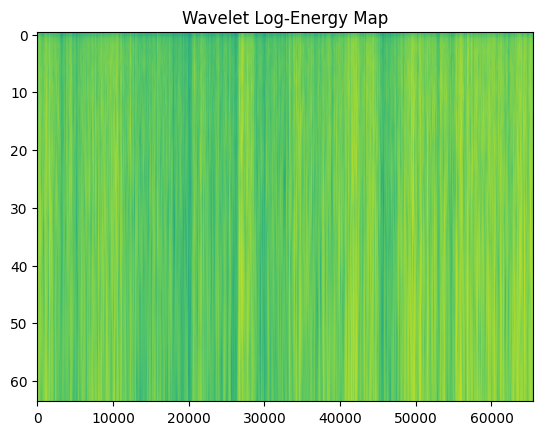

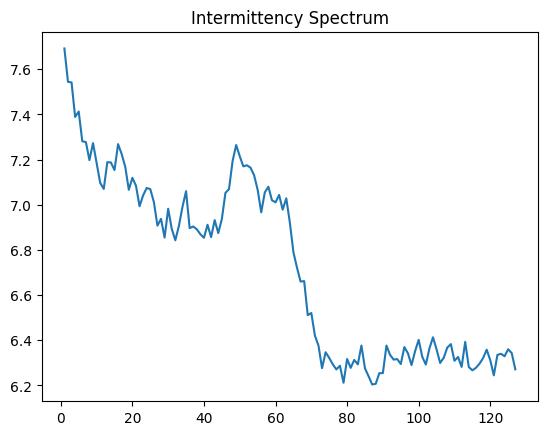

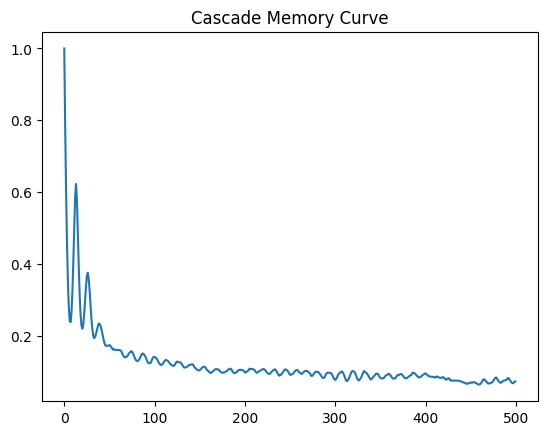

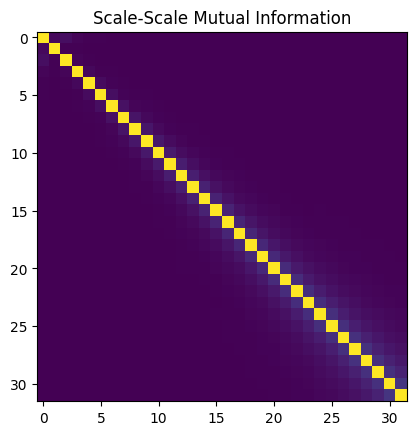

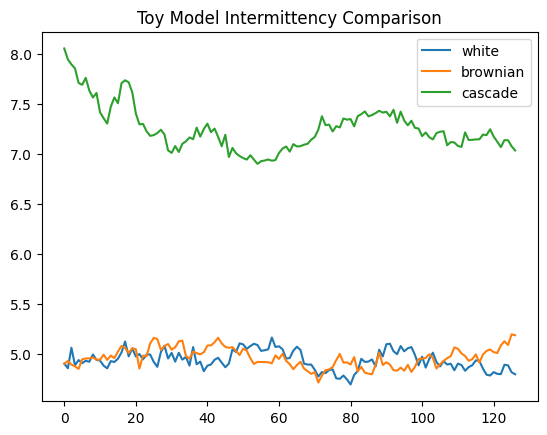

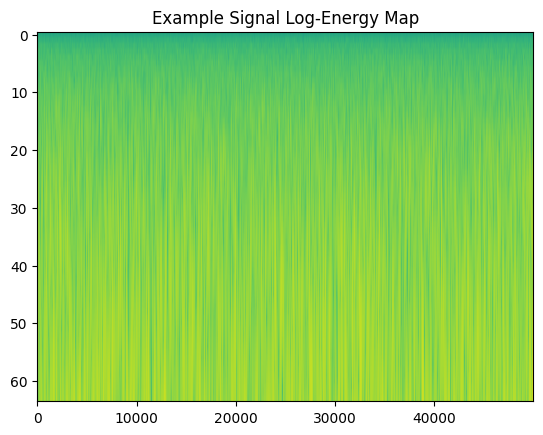

All figures generated in figures/ directory


In [ ]:

import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from sklearn.feature_selection import mutual_info_regression
import os

OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

def white_noise(n=50000):
    return np.random.normal(0,1,n)

def brownian(n=50000):
    return np.cumsum(np.random.normal(0,1,n))

def lognormal_cascade(n=65536, lam=0.05):
    levels = int(np.log2(n))
    signal = np.ones(n)
    for j in range(levels):
        blocks = 2**j
        size = n//blocks
        weights = np.exp(np.random.normal(0,np.sqrt(lam),blocks))
        for b in range(blocks):
            signal[b*size:(b+1)*size] *= weights[b]
    return signal * np.random.normal(0,1,n)

def cwt_log_energy(x):
    scales = np.arange(1,128)
    coeffs,_ = pywt.cwt(x, scales, 'morl')
    energy = np.abs(coeffs)**2
    logE = np.log(energy + 1e-12)
    return logE, scales

def cascade_memory(L):
    x = L - np.mean(L)
    corr = fftconvolve(x, x[::-1], mode='full')
    corr = corr[corr.size//2:]
    return corr/corr[0]

def scale_MI(L):
    S,T = L.shape
    MI = np.zeros((S,S))
    for i in range(S):
        for j in range(S):
            MI[i,j] = mutual_info_regression(L[i].reshape(-1,1), L[j])[0]
    return MI

def figure_log_energy_map():
    x = lognormal_cascade()
    L,_ = cwt_log_energy(x)
    plt.figure()
    plt.imshow(L[:64], aspect='auto')
    plt.title("Wavelet Log-Energy Map")
    plt.show()
    plt.close()

def figure_intermittency():
    x = lognormal_cascade()
    L,scales = cwt_log_energy(x)
    var = np.var(L,axis=1)
    plt.figure()
    plt.plot(scales,var)
    plt.title("Intermittency Spectrum")
    plt.show()
    plt.close()

def figure_cascade_memory():
    x = lognormal_cascade()
    L,_ = cwt_log_energy(x)
    C = cascade_memory(L[20])
    plt.figure()
    plt.plot(C[:500])
    plt.title("Cascade Memory Curve")
    plt.show()
    plt.close()

def figure_MI_matrix():
    x = lognormal_cascade()
    L,_ = cwt_log_energy(x)
    MI = scale_MI(L[:32])
    plt.figure()
    plt.imshow(MI)
    plt.title("Scale-Scale Mutual Information")
    plt.show()
    plt.close()

def figure_model_comparison():
    models = {
        "white":white_noise(),
        "brownian":brownian(),
        "cascade":lognormal_cascade()
    }
    plt.figure()
    for name,x in models.items():
        L,_ = cwt_log_energy(x)
        var = np.var(L,axis=1)
        plt.plot(var,label=name)
    plt.legend()
    plt.title("Toy Model Intermittency Comparison")
    plt.show()
    plt.close()

def figure_example_signal():
    x = brownian()
    L,_ = cwt_log_energy(x)
    plt.figure()
    plt.imshow(L[:64],aspect='auto')
    plt.title("Example Signal Log-Energy Map")
    plt.show()
    plt.close()

def main():
    figure_log_energy_map()
    figure_intermittency()
    figure_cascade_memory()
    figure_MI_matrix()
    figure_model_comparison()
    figure_example_signal()
    print("All figures generated in figures/ directory")


main()


In [22]:

import numpy as np
import pywt
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt

def compute_log_energy(x):
    scales = np.arange(1,128)
    coeffs,_ = pywt.cwt(x, scales, 'morl')
    L = np.log(np.abs(coeffs)**2 + 1e-12)
    L = L - np.mean(L, axis=1, keepdims=True)
    return L, scales,coeffs

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size//2:]
    return c / c[0]

def estimate_lambda2(C, min_lag=5, max_lag=500):
    lags = np.arange(len(C))
    valid = (lags > min_lag) & (lags < max_lag)

    x = np.log(lags[valid])
    y = C[valid]

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 10:
        return 0.0, False

    A = np.vstack([x, np.ones(len(x))]).T
    slope, _ = np.linalg.lstsq(A, y, rcond=None)[0]

    if abs(slope) < 1e-3:
        return 0.0, False

    lambda2 = -slope
    return lambda2, True


def white_noise(n=100000):
    return np.random.normal(0,1,n)

def brownian(n=100000):
    return np.cumsum(np.random.normal(0,1,n))

def cascade(n=65536, lam=0.05):
    levels = int(np.log2(n))
    signal = np.ones(n)
    for j in range(levels):
        blocks = 2**j
        size = n//blocks
        weights = np.exp(np.random.normal(0,np.sqrt(lam),blocks))
        for b in range(blocks):
            signal[b*size:(b+1)*size] *= weights[b]
    return signal * np.random.normal(0,1,n)


def validate_lambda2_plots(L, coeffs, n_scales=5, min_lag=5, max_lag=500):
    """
    L : log-energy field, shape (n_scales, n_times)
    n_scales : number of scales to visualize
    """

    total_scales = L.shape[0]
    example_scales = np.linspace(0, total_scales-1, n_scales, dtype=int)

    plt.figure(figsize=(20, 4*n_scales))

    plot_idx = 1
    for s in example_scales:

        # compute covariance
        U = L[s]
        C = covariance_fft(U)
        lags = np.arange(len(C))

        # estimate lambda2
        lam2, valid = estimate_lambda2(C, min_lag=min_lag, max_lag=max_lag)

        # prepare fit line
        valid_mask = (lags > min_lag) & (lags < max_lag)
        x = np.log(lags[valid_mask])
        y = C[valid_mask]

        # remove non-finite
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        if len(x) > 5:
            A = np.vstack([x, np.ones(len(x))]).T
            slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
            y_fit = slope * x + intercept
        else:
            y_fit = None

        # -----------------------------
        # Plot 0: wavelet
        # -----------------------------
        plt.subplot(n_scales, 4, plot_idx)
        plt.plot(coeffs[s][:90000],linewidth=0.1)
        plt.title(f"wavelet transform (scale = {s})")
        plot_idx += 1

        plt.subplot(n_scales, 4, plot_idx)
        plt.plot(U,linewidth=0.1)
        plt.title(f"log energy (scale = {s})")
        plot_idx += 1
        # -----------------------------
        # Plot 1: covariance vs lag
        # -----------------------------
        plt.subplot(n_scales, 4, plot_idx)
        plt.plot(lags, C, lw=1)
        plt.title(f"Scale {s}: Covariance vs lag")
        plt.xlabel("lag")
        plt.ylabel("C(lag)")
        plot_idx += 1

        # -----------------------------
        # Plot 2: covariance vs log(lag) + fit
        # -----------------------------
        plt.subplot(n_scales, 4, plot_idx)
        plt.scatter(x, y, s=8, label="data")

        if y_fit is not None:
            plt.plot(x, y_fit, color="red", lw=2,
                     label=f"fit λ²={lam2:.4f}")

        plt.title(f"Scale {s}: C vs log(lag)")
        plt.xlabel("log(lag)")
        plt.ylabel("C(lag)")
        plt.legend()
        plot_idx += 1

    plt.tight_layout()
    plt.show()



def run(x, name):

    L, scales,coeffs = compute_log_energy(x)

    lam2 = []
    for l in L:
        C = covariance_fft(l)
        lags = np.arange(1, len(C)+1)
        lam, valid = estimate_lambda2(C)
        lam2.append(lam)
    plt.plot(x,linewidth=0.1)
    plt.title(f"signal")
    plt.show()

    var_vector = [np.var(l) for l in L]
    plt.plot(scales,var_vector)
    plt.title(f"Var vs scale")
    plt.xlabel("scale")
    plt.ylabel("Var")
    plt.show()

    plt.plot(scales,lam2)
    plt.title(f"Lambda2 vs scale")
    plt.xlabel("scale")
    plt.ylabel("lambda2")
    plt.show()

    validate_lambda2_plots(L,coeffs, n_scales=5)





# White noise
Issues:
1. lambda^2 is not 0 for all scales
2. Wavelet artifacts at the end of the signal


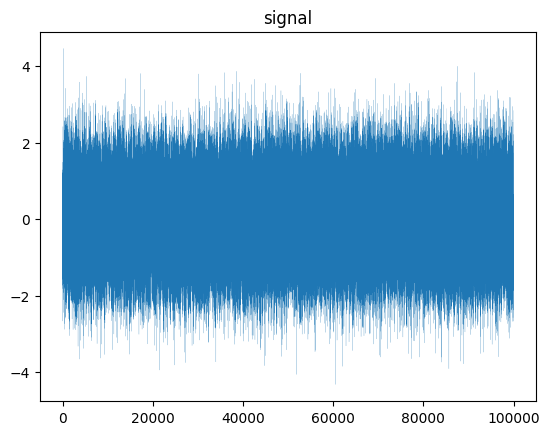

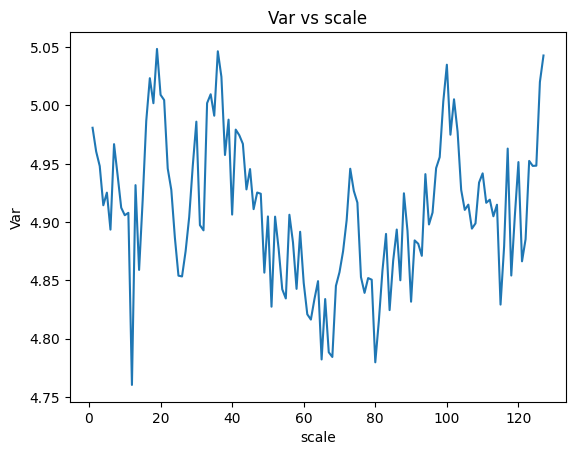

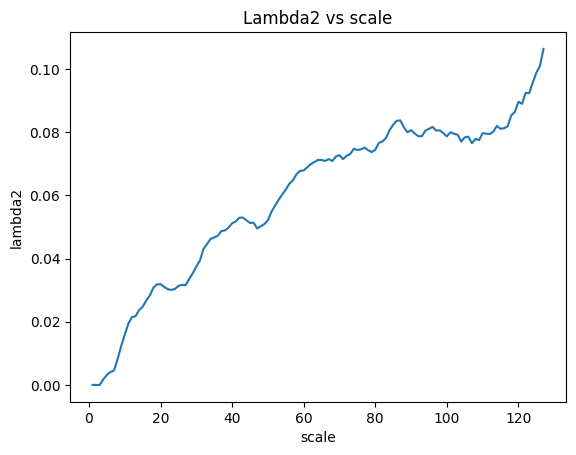

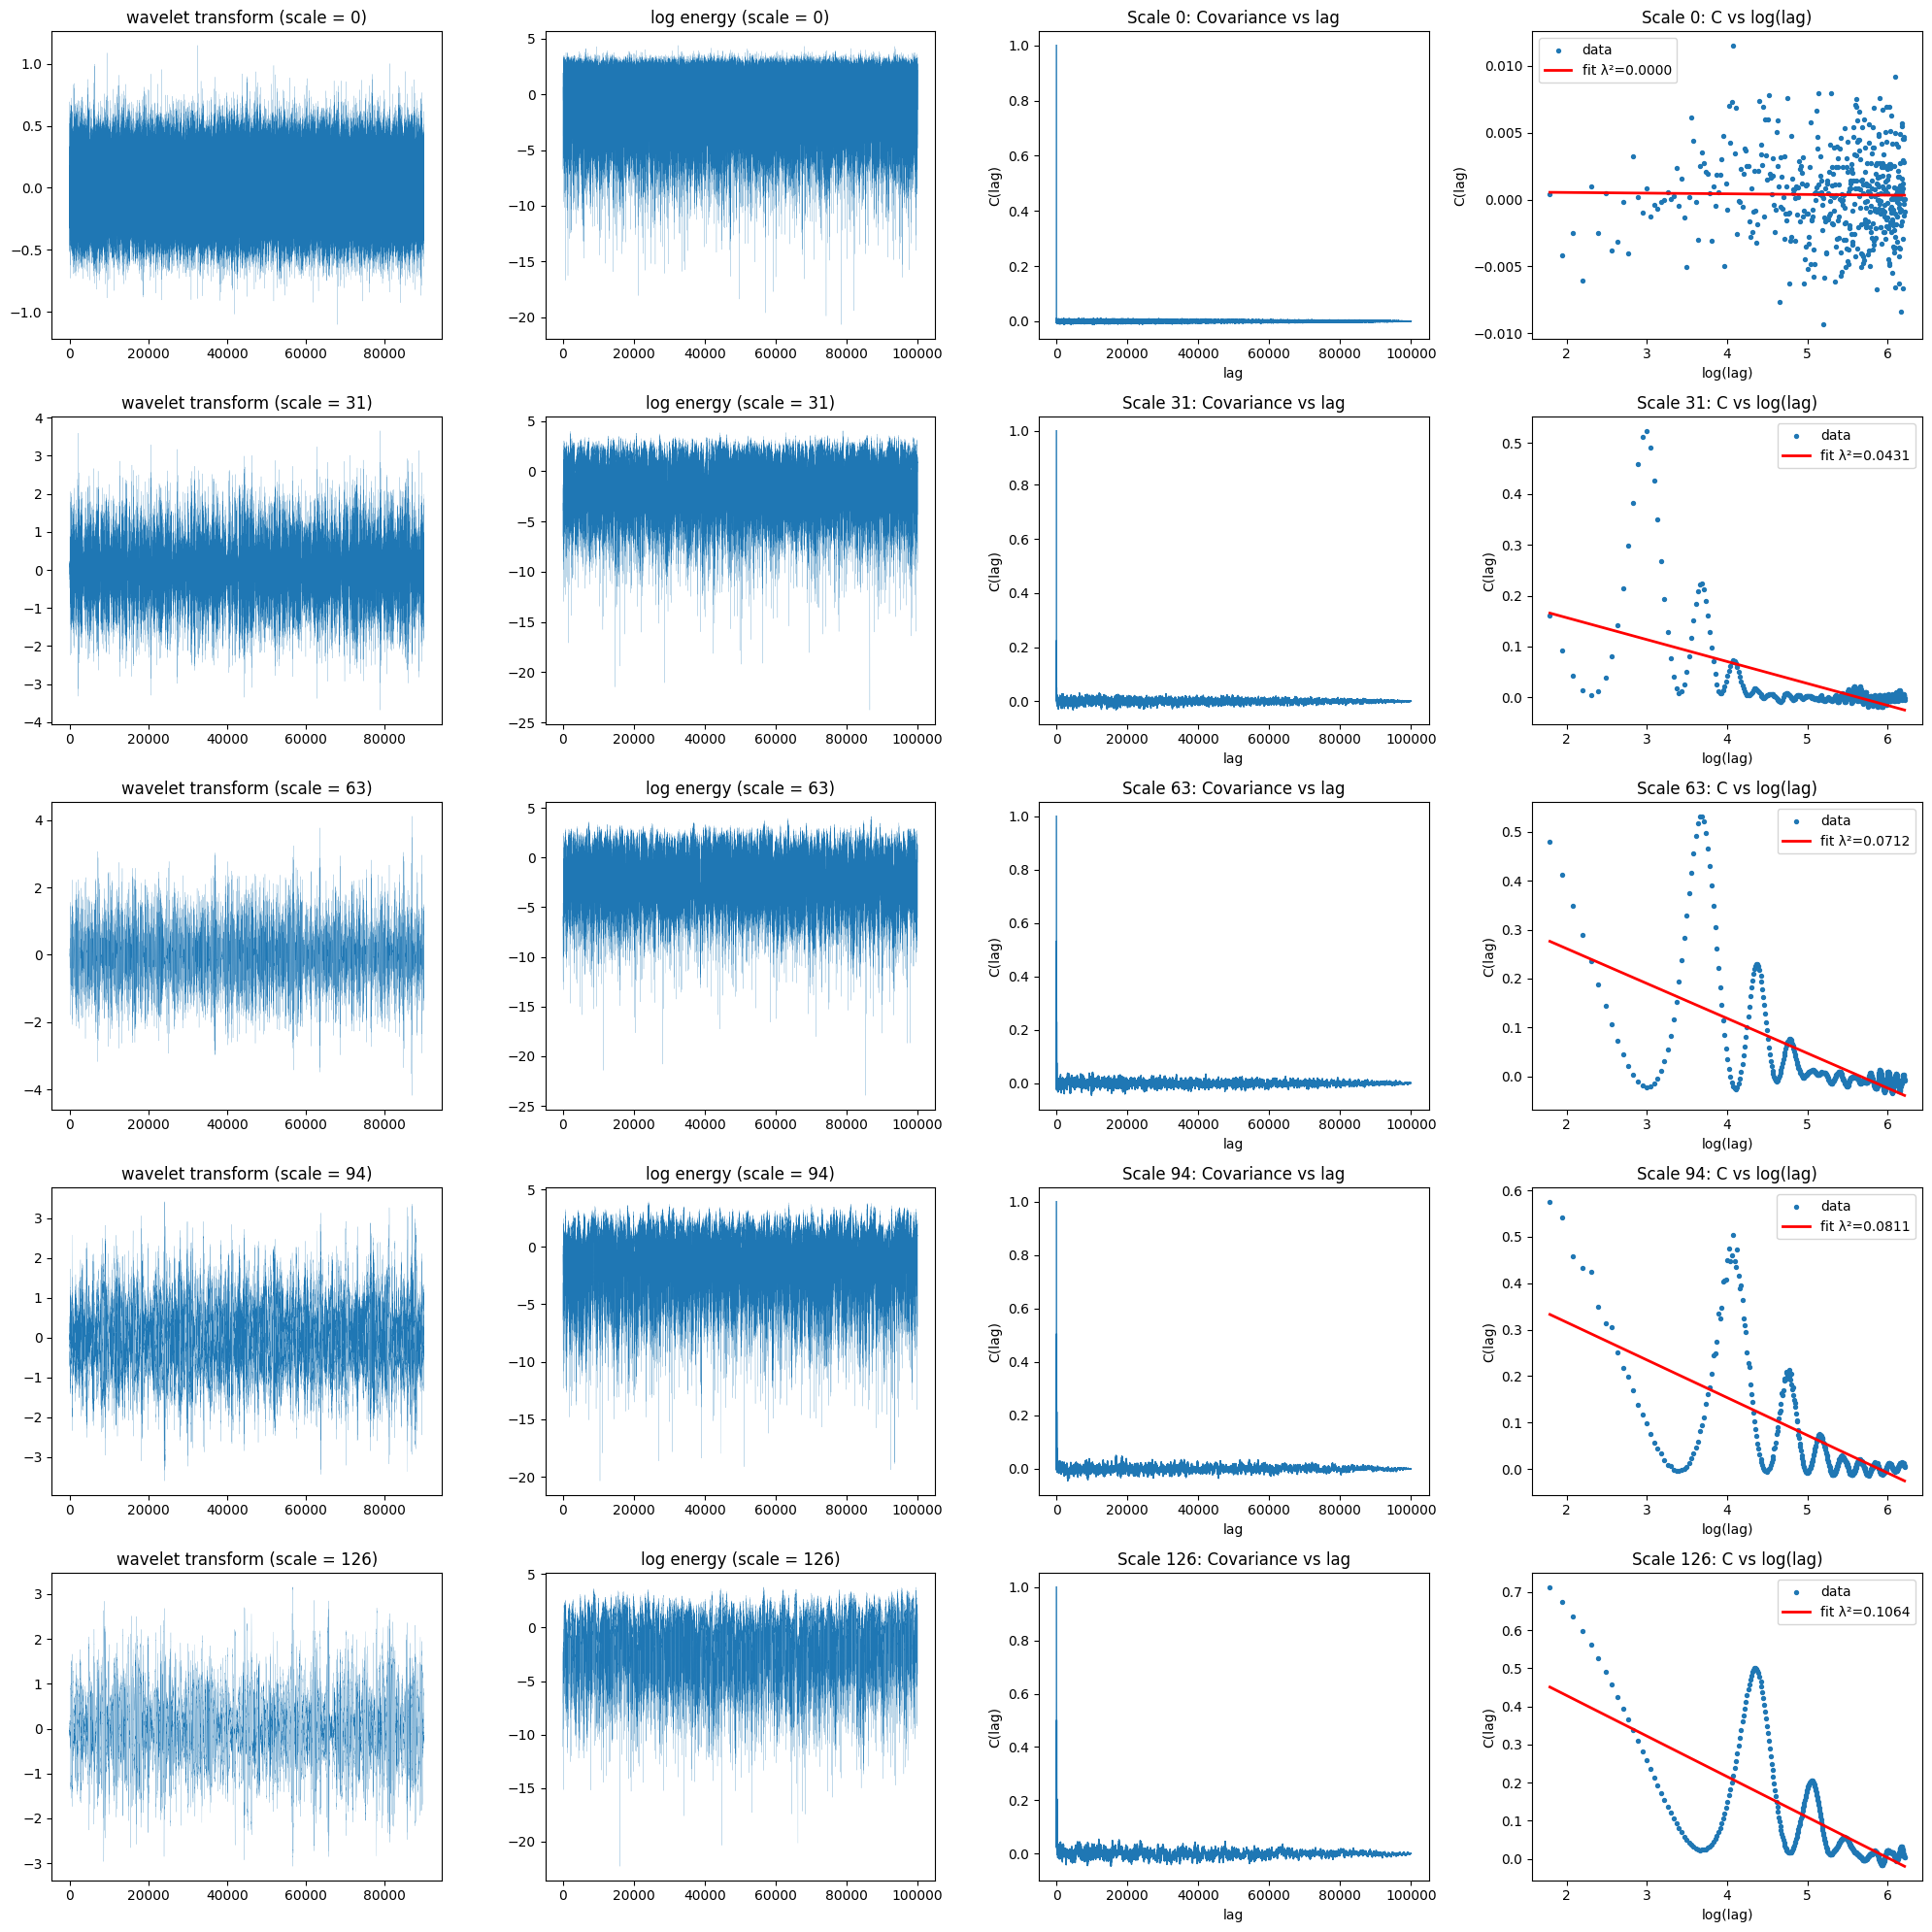

In [23]:
run(white_noise(), "White noise")

# Brownian motion

Variance comparable with WN v

Issues:
1. lambda^2 is not 0 for all scales
2. Wavelet artifacts at the end of the signal


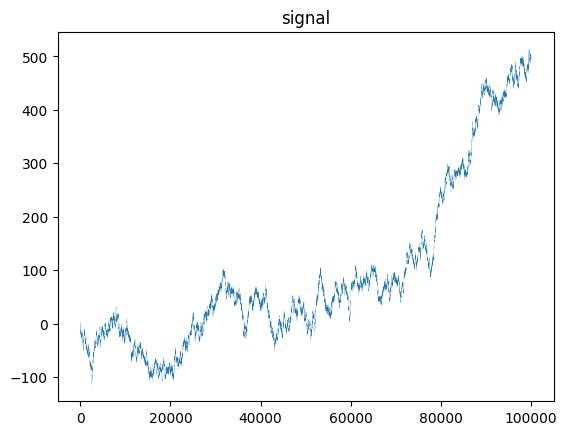

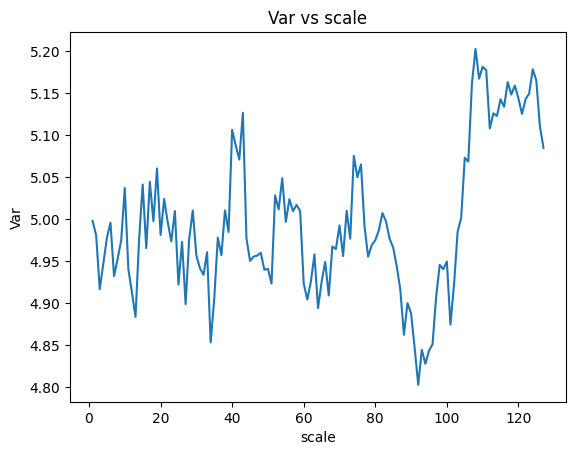

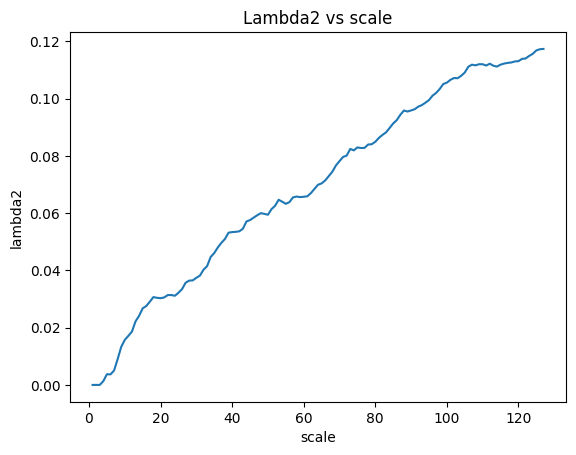

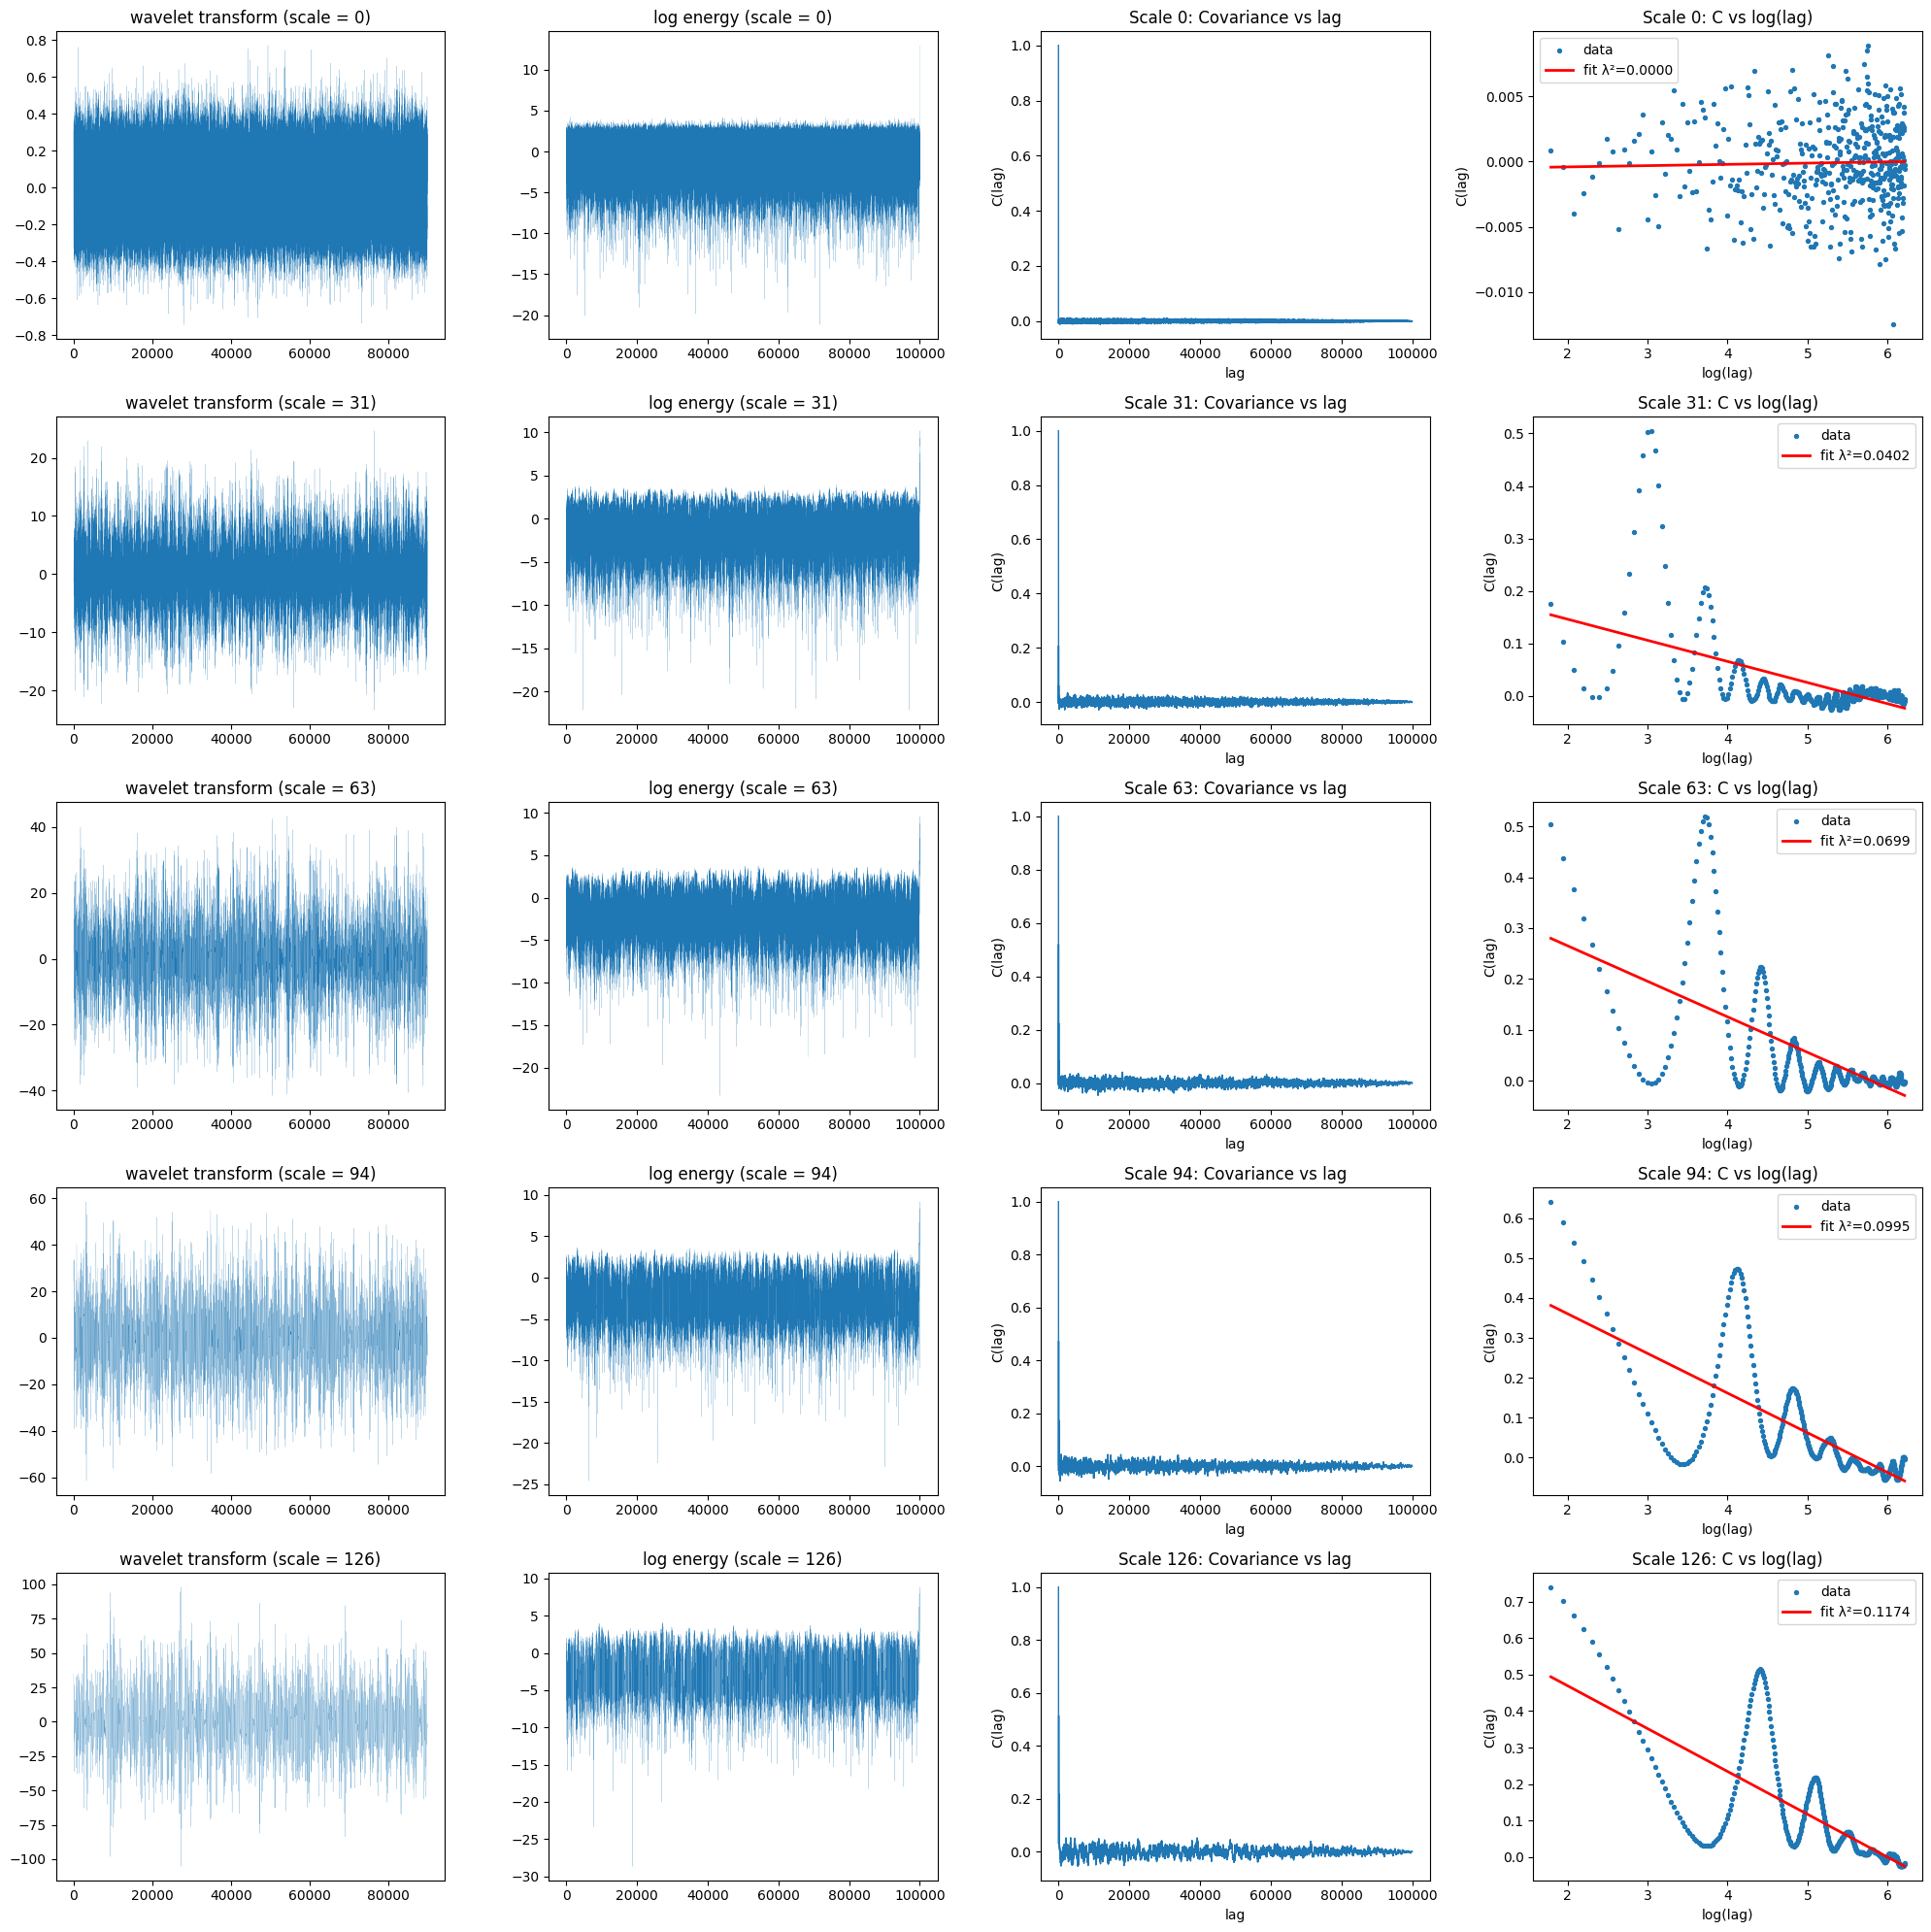

In [24]:
run(brownian(), "Brownian motion")

# Cascade

variance higher than for WN and BM v

Issues:


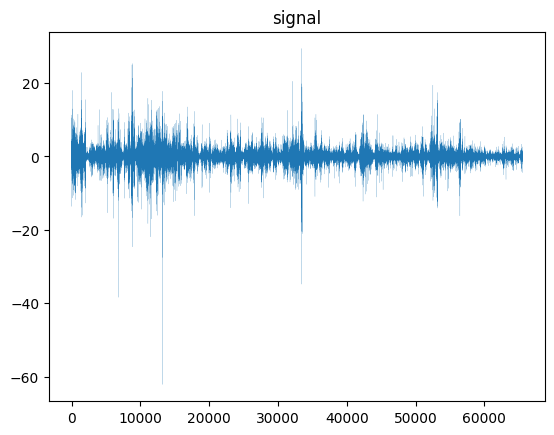

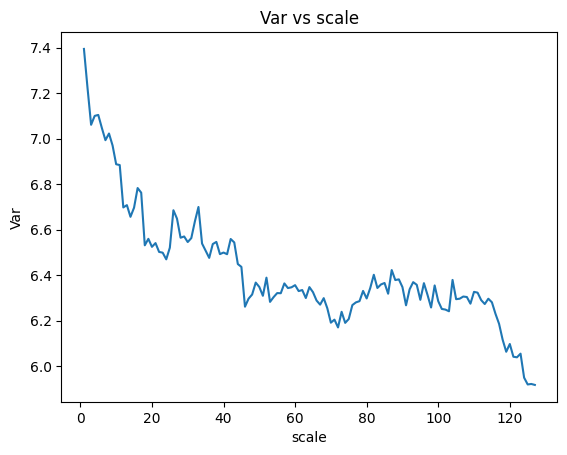

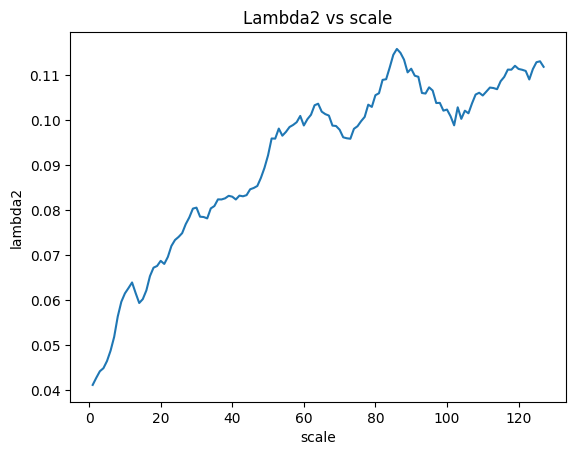

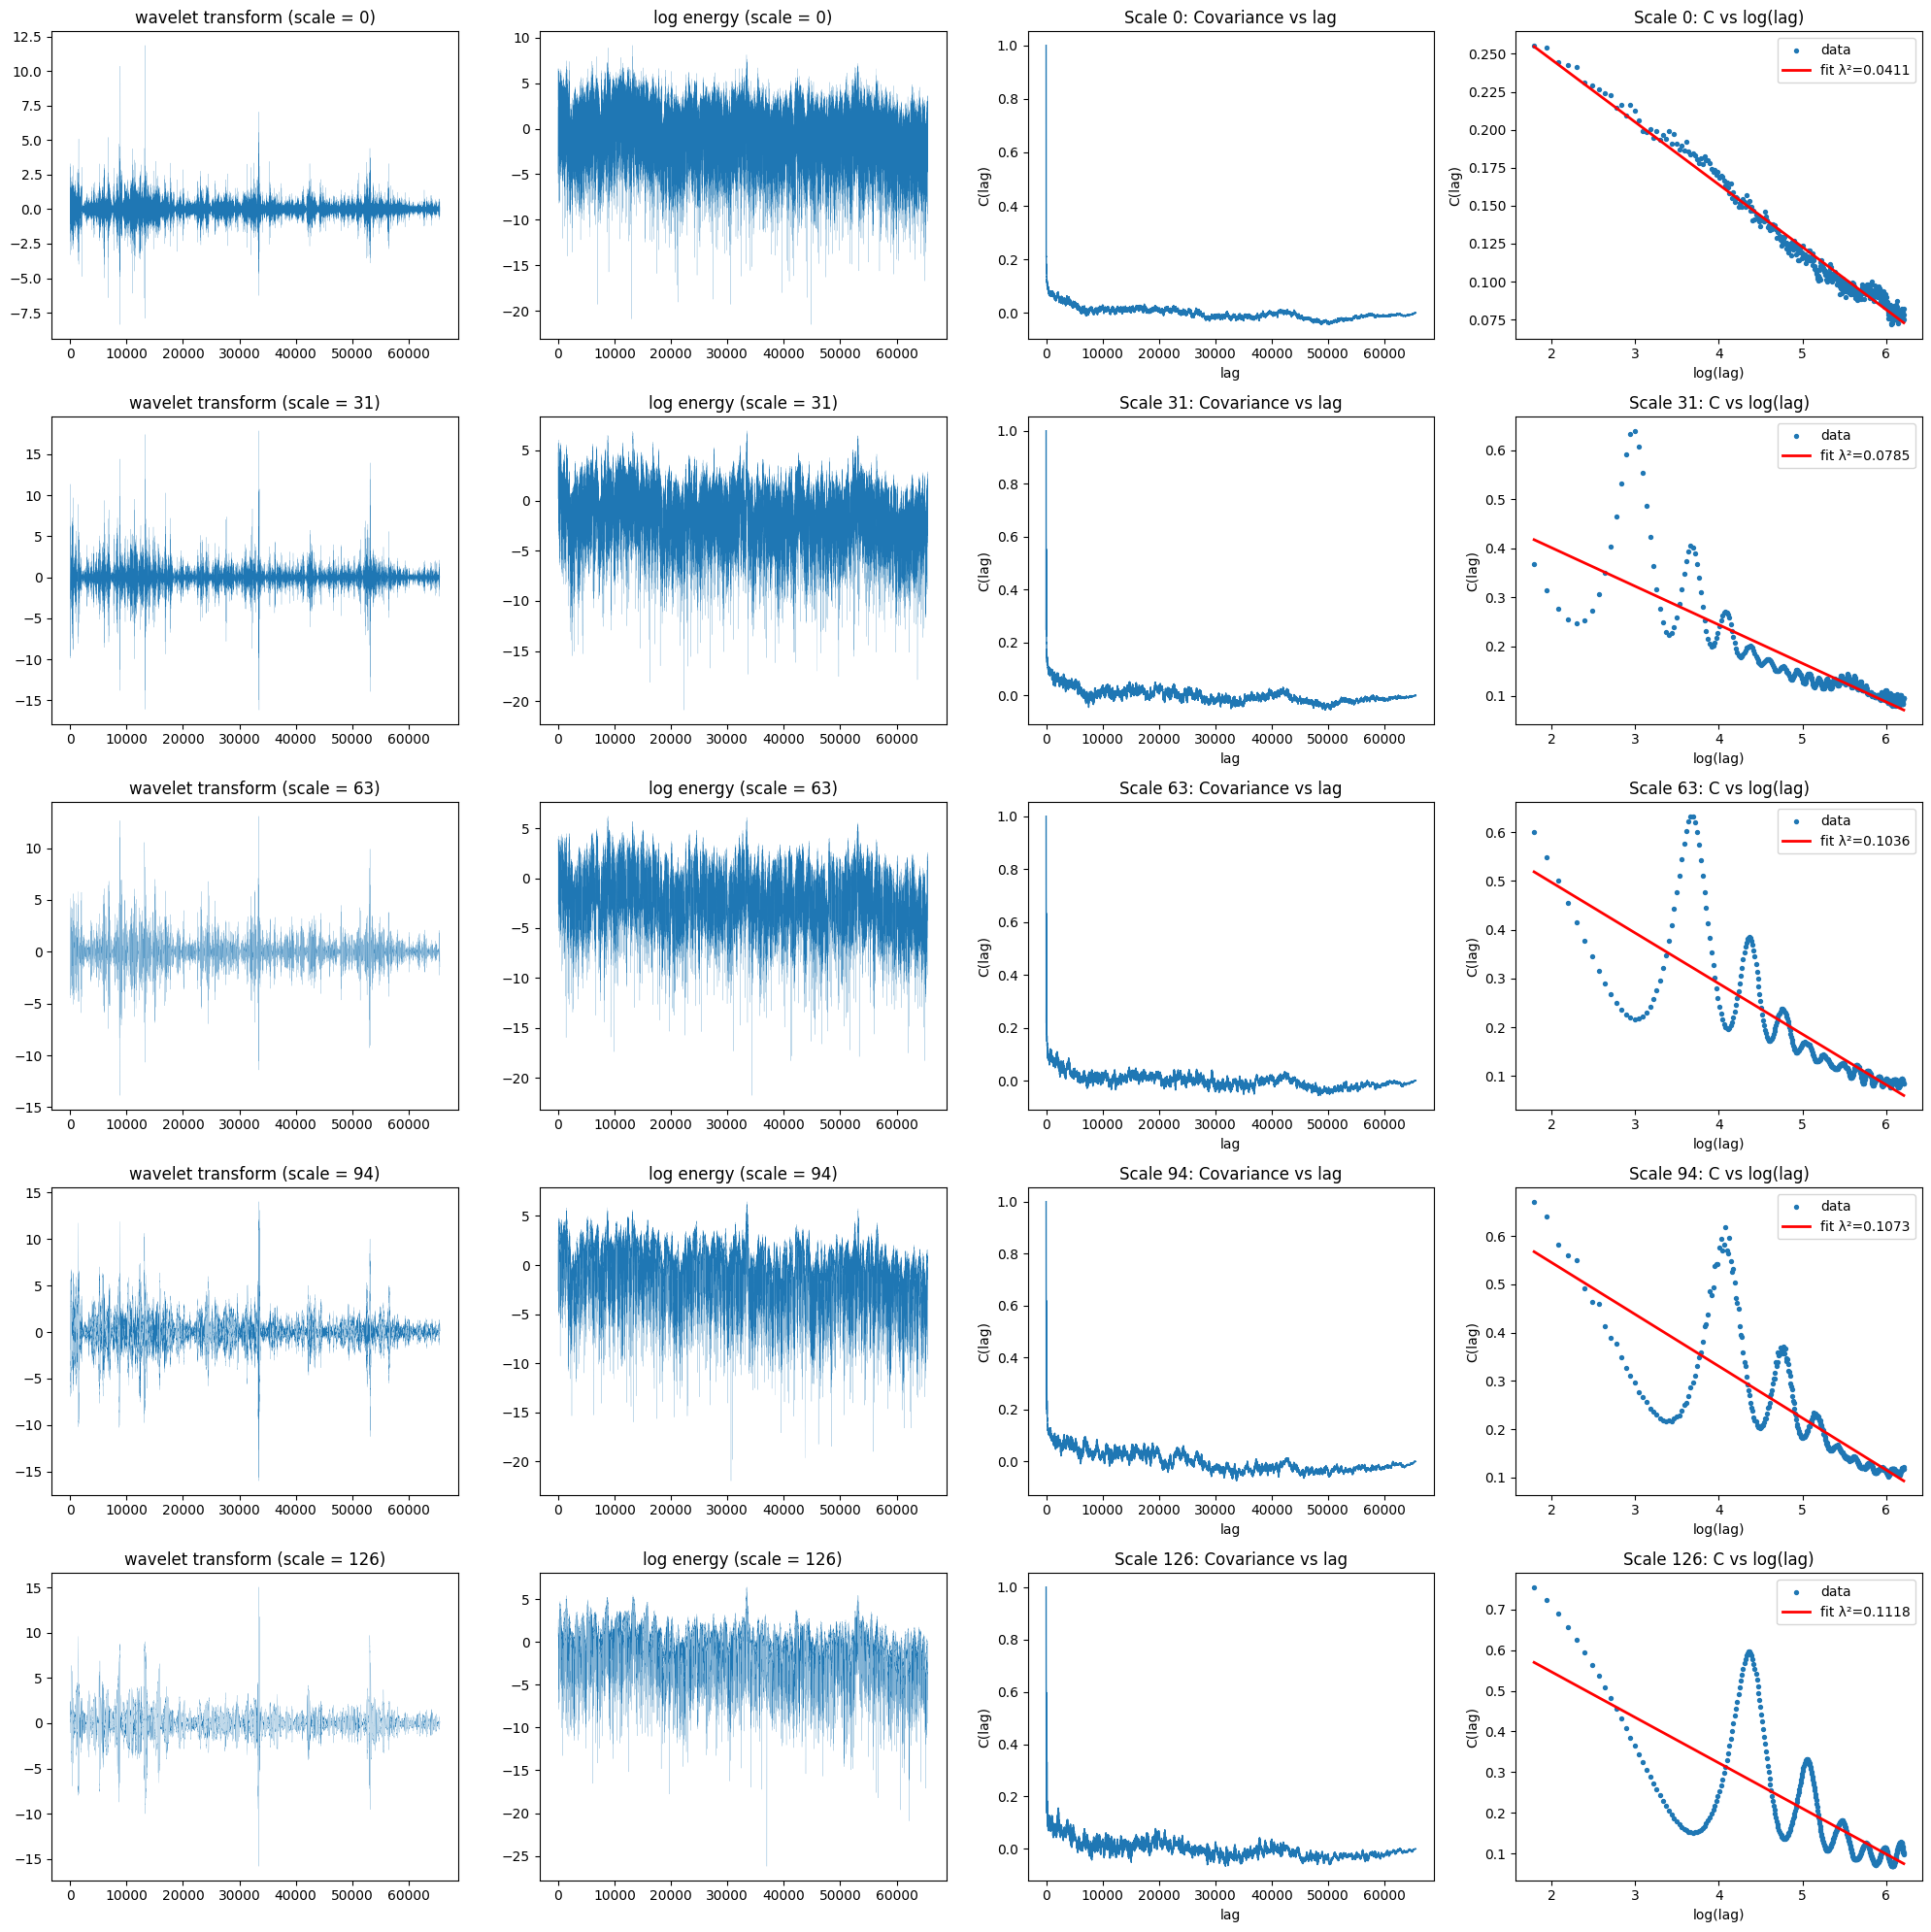

In [25]:
run(cascade(), "Cascade")